Import library yang dibutuhkan


In [22]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re

Import dataset mentah


In [7]:
df = pd.read_csv('../datasets/surat_uncleaned.csv')
df.head()

,property_name,areaWithType,square_feet,transaction,status,floor,furnishing,facing,description,price_per_sqft,price
0,2 BHK Apartment for Sale in Dindoli Surat,Carpet Area,644 sqft,New Property,Poss. by Oct '24,5 out of 10,Unfurnished,West,"Luxury project with basement parking, Solar ro...","₹2,891 per sqft",₹33.8 Lac
1,2 BHK Apartment for Sale in Althan Surat,Super Area,1278 sqft,New Property,Poss. by Jan '26,6 out of 14,Unfurnished,South -West,2 And 3 BHK Luxurious Flat for Sell In New Alt...,"₹3,551 per sqft",₹45.4 Lac
2,2 BHK Apartment for Sale in Pal Gam Surat,Super Area,1173 sqft,Resale,Ready to Move,5 out of 13,Semi-Furnished,East,This affordable 2 BHK flat is situated along a...,"₹3,800 per sqft",₹44.6 Lac
3,2 BHK Apartment for Sale in Jahangirabad Surat,Carpet Area,700 sqft,New Property,Ready to Move,6 out of 14,Unfurnished,East,2 BHK Flat For sell IN Jahangirabad Prime Loca...,"₹3,966 per sqft",₹47 Lac
4,"2 BHK Apartment for Sale in Orchid Fantasia, P...",Super Area,1250 sqft,Orchid Fantasia,New Property,Unfurnished,2,2,"Multistorey Apartment for Sale in Palanpur, Su...","₹3,600 per sqft",₹45 Lac


Cek informasi dataset


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4525 entries, 0 to 4524
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   property_name   4525 non-null   object
 1   areaWithType    4525 non-null   object
 2   square_feet     4525 non-null   object
 3   transaction     4421 non-null   object
 4   status          4524 non-null   object
 5   floor           4480 non-null   object
 6   furnishing      4185 non-null   object
 7   facing          3936 non-null   object
 8   description     3154 non-null   object
 9   price_per_sqft  4157 non-null   object
 10  price           4525 non-null   object
dtypes: object(11)
memory usage: 389.0+ KB


Cek jumlah missing value


In [4]:
df.isnull().sum()

property_name        0
areaWithType         0
square_feet          0
transaction        104
status               1
floor               45
furnishing         340
facing             589
description       1371
price_per_sqft     368
price                0
dtype: int64

Cek jumlah data duplikat


In [5]:
print(f"Duplikat data: {df.duplicated().sum()}")

Duplikat data: 109


Analisis apakahh benar terisi object -> trnyt msh byk mengandung karakter non numerik spt simmbol mata uang, satuan, dan koma


In [8]:
print(df[['price', 'square_feet', 'price_per_sqft']].head())

        price square_feet    price_per_sqft
0  ₹33.8 Lac     644 sqft  ₹2,891 per sqft 
1  ₹45.4 Lac    1278 sqft  ₹3,551 per sqft 
2  ₹44.6 Lac    1173 sqft  ₹3,800 per sqft 
3    ₹47 Lac     700 sqft  ₹3,966 per sqft 
4    ₹45 Lac    1250 sqft  ₹3,600 per sqft 


Consistency check -> hasilnya kemungkinan ada outlier


In [9]:
temp_price = pd.to_numeric(df['price'].str.replace(r'[^0-9.]', '', regex=True), errors='coerce')
print(f"Harga Minimum: {temp_price.min()}")

Harga Minimum: 1.0


In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage)
#dari hasilnya description paling banyak data kosong nya sehingga dianggap tidak lengkap

property_name      0.000000
areaWithType       0.000000
square_feet        0.000000
transaction        2.298343
status             0.022099
floor              0.994475
furnishing         7.513812
facing            13.016575
description       30.298343
price_per_sqft     8.132597
price              0.000000
dtype: float64


Pre-cleaning: Sinkroniasai nilai & type casting


In [19]:
def convert_price(value):
    if pd.isna(value): return np.nan
    value = str(value).replace('₹', '').replace(',', '').strip()
    match = re.search(r'([\d.]+)\s*(Lac|Cr)?', value) #1 Lac = 100 ribu rupe, 1Cr (crore)  = 10jt rupee
    if match:
        number = float(match.group(1))
        unit = match.group(2)
        if unit =="Lac": return number * 100000
        if unit =='Cr': return number * 10000000
        return number
    return np.nan
# 1. Konversi Kolom Price
df['price'] = df['price'].apply(convert_price)

# 2. Konversi Kolom Square Feet & Price per Sqft (Hapus semua kecuali angka dan titik)
df['square_feet'] = pd.to_numeric(df['square_feet'].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')
df['price_per_sqft'] = pd.to_numeric(df['price_per_sqft'].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')

# 3. VERIFIKASI: Harus muncul float64 di sini
print(df[['price', 'square_feet', 'price_per_sqft']].dtypes)


price             float64
square_feet       float64
price_per_sqft    float64
dtype: object


In [20]:
print("Nilai Kemiringan Data (Skewness):")
print(df[['price', 'square_feet', 'price_per_sqft']].skew())

Nilai Kemiringan Data (Skewness):
price             56.707195
square_feet       66.245899
price_per_sqft    64.192997
dtype: float64


Data Cleaning

In [ ]:
# 1. Imputasi dengan Median (Justifikasi: Skewness > 1)
df['price'] = df['price'].fillna(df['price'].median())
df['square_feet'] = df['square_feet'].fillna(df['square_feet'].median())
df['price_per_sqft'] = df['price_per_sqft'].fillna(df['price_per_sqft'].median())

# 2. Imputasi Kategorikal (Sesuai catatan dosen: MAR/MNAR beri label baru)
df['furnishing'] = df['furnishing'].fillna('Unknown')
df['facing'] = df['facing'].fillna('Unknown')
df['transaction'] = df['transaction'].fillna(df['transaction'].mode()[0])
df['status'] = df['status'].fillna(df['status'].mode()[0])

df['floor'] = df['floor'].fillna(df['floor'].mode()[0])

# 2. Imputasi Description dengan label (agar dataset lengkap/complete)
df['description'] = df['description'].fillna('No Description')

# 3. Cek apakah missing value sudah 0
print(df.isnull().sum())

property_name     0
areaWithType      0
square_feet       0
transaction       0
status            0
floor             0
furnishing        0
facing            0
description       0
price_per_sqft    0
price             0
dtype: int64
property_name     0
areaWithType      0
square_feet       0
transaction       0
status            0
floor             0
furnishing        0
facing            0
description       0
price_per_sqft    0
price             0
dtype: int64


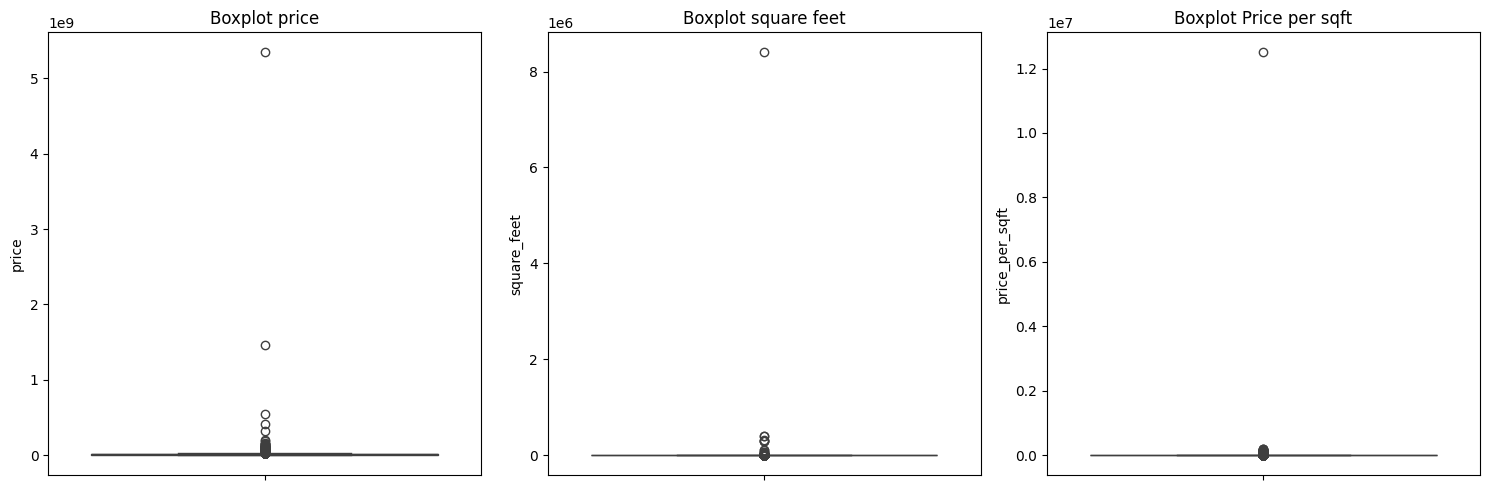

In [28]:
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
sns.boxplot(y=df['price'])
plt.title('Boxplot price')

plt.subplot(1,3,2)
sns.boxplot(y=df['square_feet'])
plt.title('Boxplot square feet')

plt.subplot(1,3,3)
sns.boxplot(y=df['price_per_sqft'])
plt.title('Boxplot Price per sqft')
plt.tight_layout()
plt.show()

In [26]:
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# Mari kita cek batas untuk Price
low_p, up_p = detect_outliers_iqr(df['price'])
print(f"Batas Bawah Harga: {low_p}, Batas Atas Harga: {up_p}")

# Cek berapa banyak data di atas batas atas
outliers_count = df[df['price'] > up_p].shape[0]
print(f"Jumlah Outlier di atas batas: {outliers_count}")

Batas Bawah Harga: -8425000.0, Batas Atas Harga: 25855000.0
Jumlah Outlier di atas batas: 383


In [24]:
# Cek harga yang tidak masuk akal (misal di bawah 100.000 Rupee)
noise_price = df[df['price'] < 100000]
print(f"Jumlah data harga tidak valid: {len(noise_price)}")

# Cek luas yang tidak masuk akal (misal di bawah 100 sqft untuk apartemen)
noise_area = df[df['square_feet'] < 100]
print(f"Jumlah data luas tidak valid: {len(noise_area)}")

Jumlah data harga tidak valid: 0
Jumlah data luas tidak valid: 83


In [25]:
# Cek nilai unik di kolom furnishing dan facing
print("Unique Furnishing:", df['furnishing'].unique())
print("Unique Facing:", df['facing'].unique())

Unique Furnishing: ['Unfurnished' 'Semi-Furnished' '2' 'Anand Aspire' 'East' '1' 'Furnished'
 'Unknown' '3' '1 Covered,' '2 Covered' '1 Covered' 'Freehold' 'West'
 '26 Covered' 'Main Road' 'No' 'North' '1 Open' '6' 'Co-operative Society'
 '> 10' '4' 'Nilkanth Seven Homes' 'Aagam Navkar' '10 Open'
 'Vinayak Enclave' '5 Covered,' 'South -West'
 'Pool, Garden/Park, Main Road' 'Garden/Park, Main Road' '7 m' '30 m'
 '50 Covered,' 'South' '12 m' 'Yes' 'Gruham Luxuria' '2 Covered,' 'Congo'
 'Prayosha Shine' 'North - East' 'Vaishnodevi Ideal Homes' 'Santvan Lexon'
 'Sangini Epitome' '100 Covered' 'Nirvana Gladiolus' '7' '5 Covered' '5'
 'Raghuvir Spalex' '50 Open' 'South - East' 'North - West' '20 m'
 '20 Open' 'Garden/Park' '10 m' 'Sattvam' 'Pramukh Amaya' 'Sun Sarvam'
 '3 Covered' '2 Open' '6 m' 'Avadh Kimberly' 'Happy Glorious' 'DMD Aura'
 'Freedom Tower' '15 m' 'Surya Signature' 'Someshwara Enclave'
 'Green Valley Row House' 'Green Valley' 'Vatsalya Bungalows' 'DMD Signus'
 '10 Covered,' '

Handling Outlier

In [29]:
from scipy.stats.mstats import winsorize

# 1. Trimming: Hapus luas yang tidak logis (< 100 sqft)
df = df[df['square_feet'] >= 100]

# 2. Winsorizing: Capping nilai ekstrem pada persentil 99
# limits=[0, 0.01] artinya kita membatasi 1% data teratas
df['price'] = winsorize(df['price'], limits=[0, 0.01])
df['square_feet'] = winsorize(df['square_feet'], limits=[0, 0.01])
df['price_per_sqft'] = winsorize(df['price_per_sqft'], limits=[0, 0.01])

# 3. Cek Skewness lagi setelah handling
print("Skewness setelah Handling Outlier:")
print(df[['price', 'square_feet', 'price_per_sqft']].skew())

Skewness setelah Handling Outlier:
price             2.828737
square_feet       2.198727
price_per_sqft    2.821211
dtype: float64


Cek data imbalance atau balance

In [30]:
print(df['transaction'].value_counts(normalize=True) * 100)
print("-" * 30)
print(df['status'].value_counts(normalize=True) * 100)

transaction
Resale                          50.765421
New Property                    33.385862
Unfurnished                      8.734804
Semi-Furnished                   1.778478
Furnished                        1.440792
2                                0.540297
3                                0.495272
No                               0.427735
Congo                            0.427735
1                                0.360198
Yes                              0.337686
5                                0.247636
4                                0.157587
Main Road                        0.135074
Soham Elegance                   0.067537
Orchid Gardenia                  0.067537
6                                0.067537
Orchid Fantasia                  0.045025
Jolly Residency                  0.045025
Raghuvir Silverstone             0.045025
Casa Rivera                      0.045025
Main Road, Garden/Park           0.022512
1 Covered                        0.022512
Other                 

Penanganan imbalance - pakai filtering

In [35]:
# Tentukan kategori yang valid
valid_transactions = ['Resale', 'New Property']

# Ubah kategori selain itu menjadi 'Other'
df['transaction'] = df['transaction'].apply(lambda x: x if x in valid_transactions else 'Other')

# Lakukan hal yang sama untuk status (ambil yang Ready to Move saja)
df['status'] = df['status'].apply(lambda x: 'Ready to Move' if x == 'Ready to Move' else 'Under Construction')

Normalisasi

In [34]:
# 1. Ekstrak angka saja dari kolom floor
# Contoh: '5 out of 10' akan menjadi 5.0
df['floor'] = df['floor'].astype(str).str.extract(r'(\d+)').astype(float)

# 2. Karena tadi ada yang error, mungkin muncul NaN baru. 
# Isi NaN tersebut dengan modus (MCAR handling)
df['floor'] = df['floor'].fillna(df['floor'].mode()[0])

# 3. Pastikan fitur yang dipilih sekarang benar-benar bersih
features = ['price', 'square_feet', 'price_per_sqft', 'floor']
X = df[features]

# 4. Baru jalankan Standarisasi
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data sukses dinormalisasi. Skala data 5 baris pertama:")
print(X_scaled[:5])

Data sukses dinormalisasi. Skala data 5 baris pertama:
[[-0.64984766 -0.75927425 -0.76022533 -0.05958242]
 [-0.55166345 -0.28718952 -0.57413591  0.27714163]
 [-0.55843478 -0.3653739  -0.50392945 -0.05958242]
 [-0.5381208  -0.71757592 -0.45712515  0.27714163]
 [-0.55504911 -0.30803868 -0.56032019 -0.05958242]]


EDA

In [36]:
# Melihat rangkuman statistik untuk kolom numerik
print(df[['price', 'square_feet', 'price_per_sqft', 'floor']].describe())

              price  square_feet  price_per_sqft        floor
count  4.442000e+03  4442.000000     4442.000000  4442.000000
mean   1.105764e+07  1663.689554     5587.277578     5.176947
std    1.181586e+07  1343.130426     3547.081399     2.970125
min    1.000000e+05   100.000000        1.000000     1.000000
25%    4.465000e+06   813.000000     3751.000000     3.000000
50%    7.100000e+06  1266.500000     4700.000000     5.000000
75%    1.300000e+07  2000.000000     6000.000000     7.000000
max    7.200000e+07  8000.000000    24306.000000    59.000000


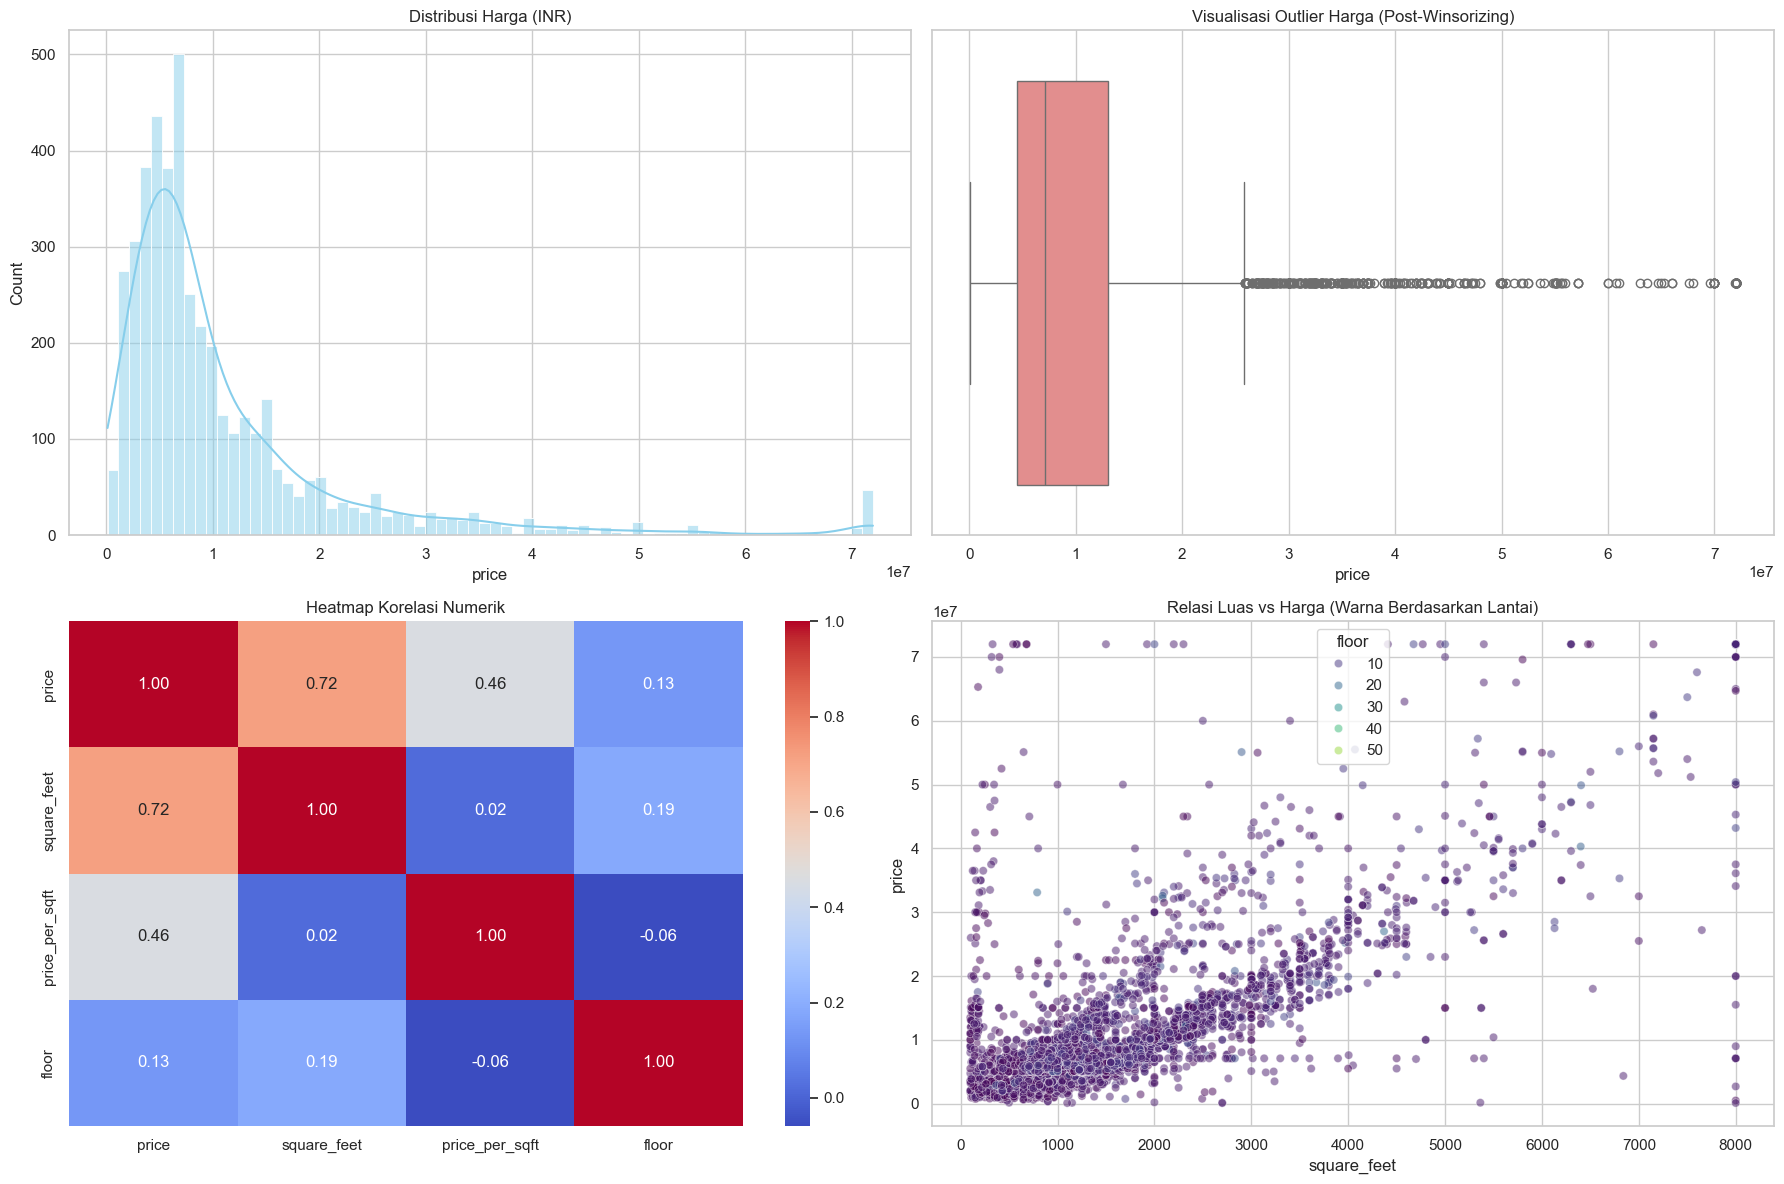

In [38]:
# Set tema visualisasi
sns.set(style="whitegrid")
plt.figure(figsize=(18, 12))

# 1. Distribusi Data (Histogram)
plt.subplot(2, 2, 1)
sns.histplot(df['price'], kde=True, color='skyblue')
plt.title('Distribusi Harga (INR)')

# 2. Outlier Visual (Boxplot) - Setelah Cleaning
plt.subplot(2, 2, 2)
sns.boxplot(x=df['price'], color='lightcoral')
plt.title('Visualisasi Outlier Harga (Post-Winsorizing)')

# 3. Korelasi (Heatmap)
plt.subplot(2, 2, 3)
corr = df[['price', 'square_feet', 'price_per_sqft', 'floor']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Numerik')

# 4. Relasi Fitur (Scatter Plot: Luas vs Harga)
# Dalam clustering, fitur lain sering dianggap 'target' untuk melihat relasi
plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x='square_feet', y='price', alpha=0.5, hue='floor', palette='viridis')
plt.title('Relasi Luas vs Harga (Warna Berdasarkan Lantai)')

plt.tight_layout()
plt.show()

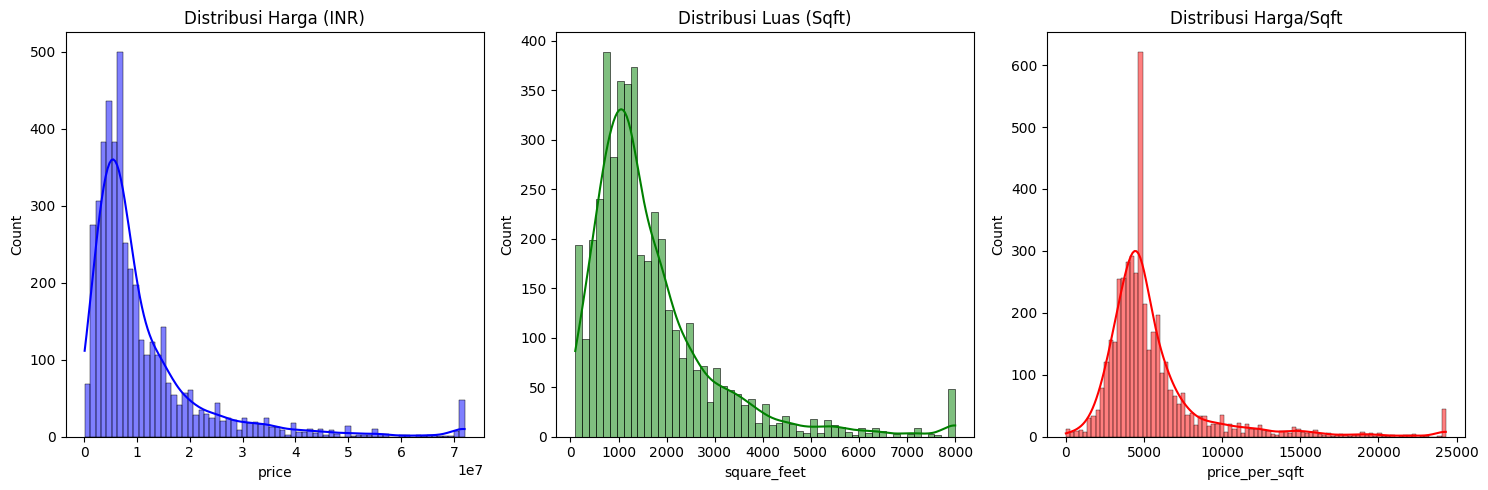

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Distribusi Harga (INR)')

plt.subplot(1, 3, 2)
sns.histplot(df['square_feet'], kde=True, color='green')
plt.title('Distribusi Luas (Sqft)')

plt.subplot(1, 3, 3)
sns.histplot(df['price_per_sqft'], kde=True, color='red')
plt.title('Distribusi Harga/Sqft')

plt.tight_layout()
plt.show()

Featue selection & Extraction

In [42]:
# 1. Feature Extraction: Mengubah Furnishing menjadi Numerik (Ordinal)
furnish_map = {'Unfurnished': 0, 'Semi-Furnished': 1, 'Furnished': 2, 'Unknown': 0}
df['furnishing_encoded'] = df['furnishing'].map(furnish_map)

# 2. Feature Selection: Memilih fitur final
# Kita tambahkan furnishing_encoded ke dalam list fitur
features = ['price', 'square_feet', 'price_per_sqft', 'floor', 'furnishing_encoded']
X = df[features]

# 3. Normalization (Validasi Skala)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Fitur Terpilih:", features)
print("Ukuran Matriks Fitur:", X_scaled.shape)

Fitur Terpilih: ['price', 'square_feet', 'price_per_sqft', 'floor', 'furnishing_encoded']
Ukuran Matriks Fitur: (4442, 5)


In [45]:
# Cek di mana NaN berada
print("Jumlah NaN sebelum pembersihan final:")
print(X.isnull().sum())

# Cara paling ampuh: Drop baris yang mengandung NaN atau Inf
# Karena jumlah data kita ribuan, menghapus beberapa baris NaN tidak akan merusak model
X = X.replace([np.inf, -np.inf], np.nan).dropna()

# Update X_scaled dengan data yang sudah benar-benar bersih
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nJumlah baris setelah dibersihkan:", X_scaled.shape[0])

Jumlah NaN sebelum pembersihan final:
price                   0
square_feet             0
price_per_sqft          0
floor                   0
furnishing_encoded    877
dtype: int64

Jumlah baris setelah dibersihkan: 3565


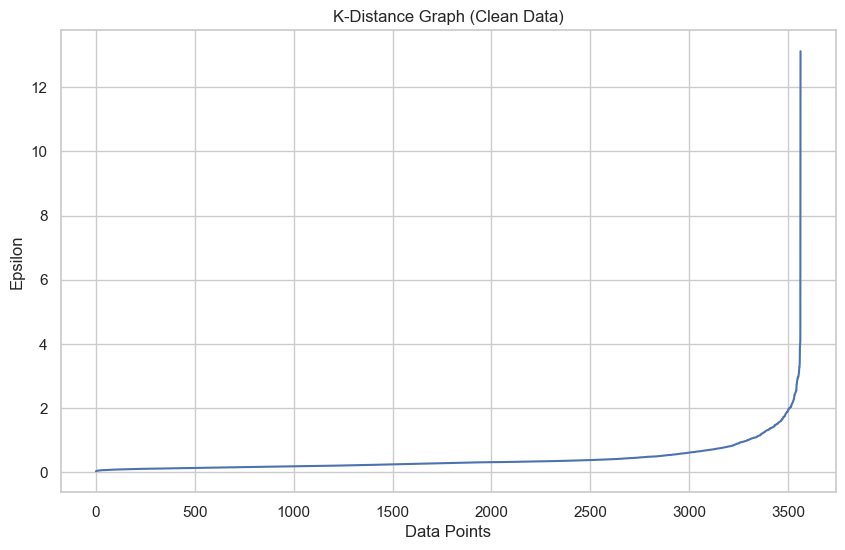

In [46]:
from sklearn.neighbors import NearestNeighbors

# MinPts = 10 (2 * 5 fitur)
min_pts = 10
neighbors = NearestNeighbors(n_neighbors=min_pts)
neighbors_fit = neighbors.fit(X_scaled) # Harusnya sudah tidak error di sini
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Ambil jarak ke tetangga ke-10, urutkan
distances = np.sort(distances[:, min_pts-1], axis=0)

# Visualisasi
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-Distance Graph (Clean Data)')
plt.ylabel('Epsilon')
plt.xlabel('Data Points')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

# Kita tes nilai di area siku (0.5 atau 0.6 biasanya paling pas untuk data standarisasi)
best_eps = 0.5 
dbscan = DBSCAN(eps=best_eps, min_samples=10)
clusters = dbscan.fit_predict(X_scaled)

unique, counts = np.unique(clusters, return_counts=True)
print(f"Hasil Clustering dengan Epsilon {best_eps}:")
print(dict(zip(unique, counts)))

Hasil Clustering dengan Epsilon 0.5:
{np.int64(-1): np.int64(517), np.int64(0): np.int64(2232), np.int64(1): np.int64(405), np.int64(2): np.int64(363), np.int64(3): np.int64(12), np.int64(4): np.int64(13), np.int64(5): np.int64(23)}


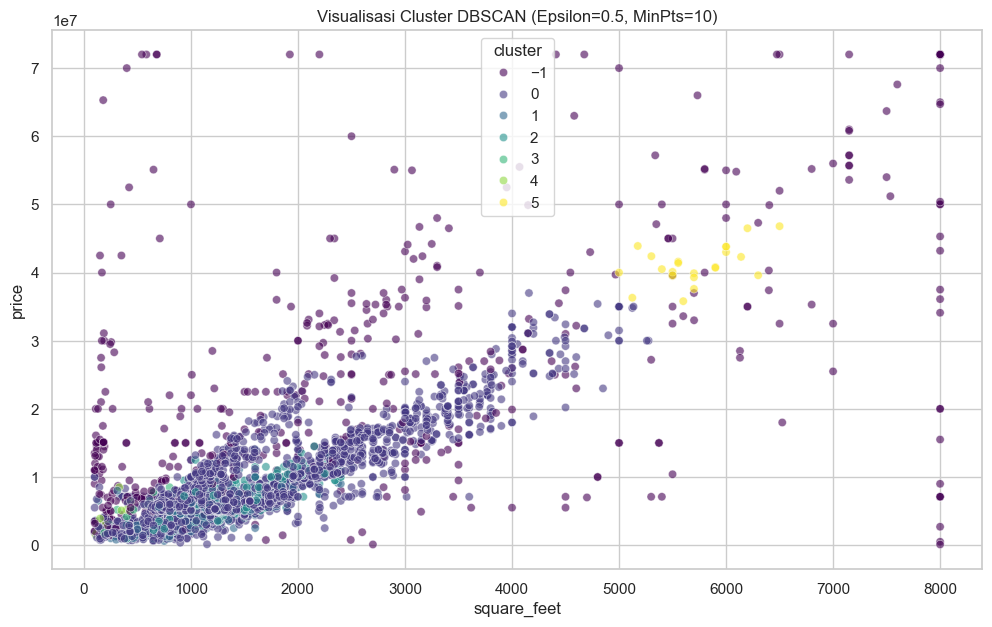

In [50]:
# 1. Jalankan DBSCAN (Pastikan X_scaled sudah siap)
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)
clusters = dbscan.fit_predict(X_scaled)

# 2. Definisikan df_result (Cara paling aman: pakai data X yang asli)
# Karena X adalah fitur numerik kita, kita ambil datanya saja
df_result = X.copy()

# 3. Masukkan hasil cluster
df_result['cluster'] = clusters

# 4. Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_result, x='square_feet', y='price', hue='cluster', palette='viridis', alpha=0.6)
plt.title('Visualisasi Cluster DBSCAN (Epsilon=0.5, MinPts=10)')
plt.show()

In [51]:
from sklearn.metrics import silhouette_score

# Hitung score (Hanya untuk data yang bukan noise)
mask = clusters != -1
if len(set(clusters[mask])) > 1:
    score = silhouette_score(X_scaled[mask], clusters[mask])
    print(f"Silhouette Score (Excluding Noise): {score:.4f}")
else:
    print("Tidak cukup cluster untuk menghitung Silhouette Score.")

Silhouette Score (Excluding Noise): 0.2458


In [52]:
# Menghitung rata-rata tiap fitur per cluster
profiling = df_result.groupby('cluster').agg({
    'price': ['mean', 'min', 'max'],
    'square_feet': 'mean',
    'floor': 'mean',
    'cluster': 'count'
}).rename(columns={'count': 'jumlah_data'})

print(profiling)

                price                          square_feet     floor  \
                 mean         min         max         mean      mean   
cluster                                                                
-1       2.524750e+07    100000.0  72000000.0  2802.382979  5.851064   
 0       8.993383e+06    130000.0  37000000.0  1620.425627  5.454301   
 1       4.732667e+06    600000.0  11500000.0  1078.407407  4.096296   
 2       6.102534e+06    950000.0  14500000.0  1283.559229  4.920110   
 3       4.695833e+06   1800000.0   8500000.0   418.916667  4.583333   
 4       4.027692e+06   1530000.0   8500000.0   240.153846  1.384615   
 5       4.109565e+07  35800000.0  46800000.0  5706.391304  6.130435   

            cluster  
        jumlah_data  
cluster              
-1              517  
 0             2232  
 1              405  
 2              363  
 3               12  
 4               13  
 5               23  


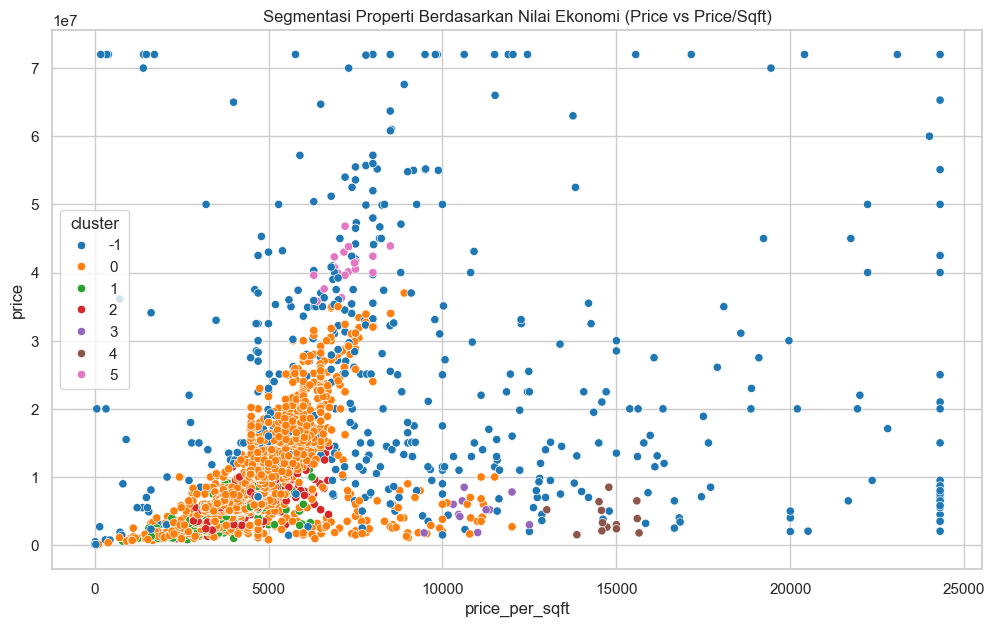

In [53]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_result, x='price_per_sqft', y='price', hue='cluster', palette='tab10')
plt.title('Segmentasi Properti Berdasarkan Nilai Ekonomi (Price vs Price/Sqft)')
plt.show()